# Reproduce the paper's figures and table

This notebook regenerates **Fig. 2**, **Fig. 3** and **Table 1** of *ModalFidelity: Routing Modalities for Deepfake Detection on a Budget*

In [1]:
import os
from IPython.display import Image, Markdown, display

from modalfidelity.paths import REPO_ROOT, saved_data_dir
from modalfidelity.plots import claims, fig2, fig3, table1

DATA = saved_data_dir()
OUT = os.path.join(REPO_ROOT, "outputs", "figures")
# the figures are regenerated on every run, so replacing the previous run's copies is intended
OVERWRITE = True
# paths are printed relative to the repository, so the saved outputs hold no machine paths
print("data:", os.path.relpath(DATA, REPO_ROOT))
print("figures ->", os.path.relpath(OUT, REPO_ROOT))

data: data
figures -> outputs/figures


## Fig. 2: with no budget cap, does picking the stream still matter?

Per-window confidence by forgery type. Confidence is the detector's margin $s_t^m-\tau^m$, rescaled per detector to $[-1,1]$, so 0 is the decision boundary. Every window is affordable, but at most one stream per window is read.

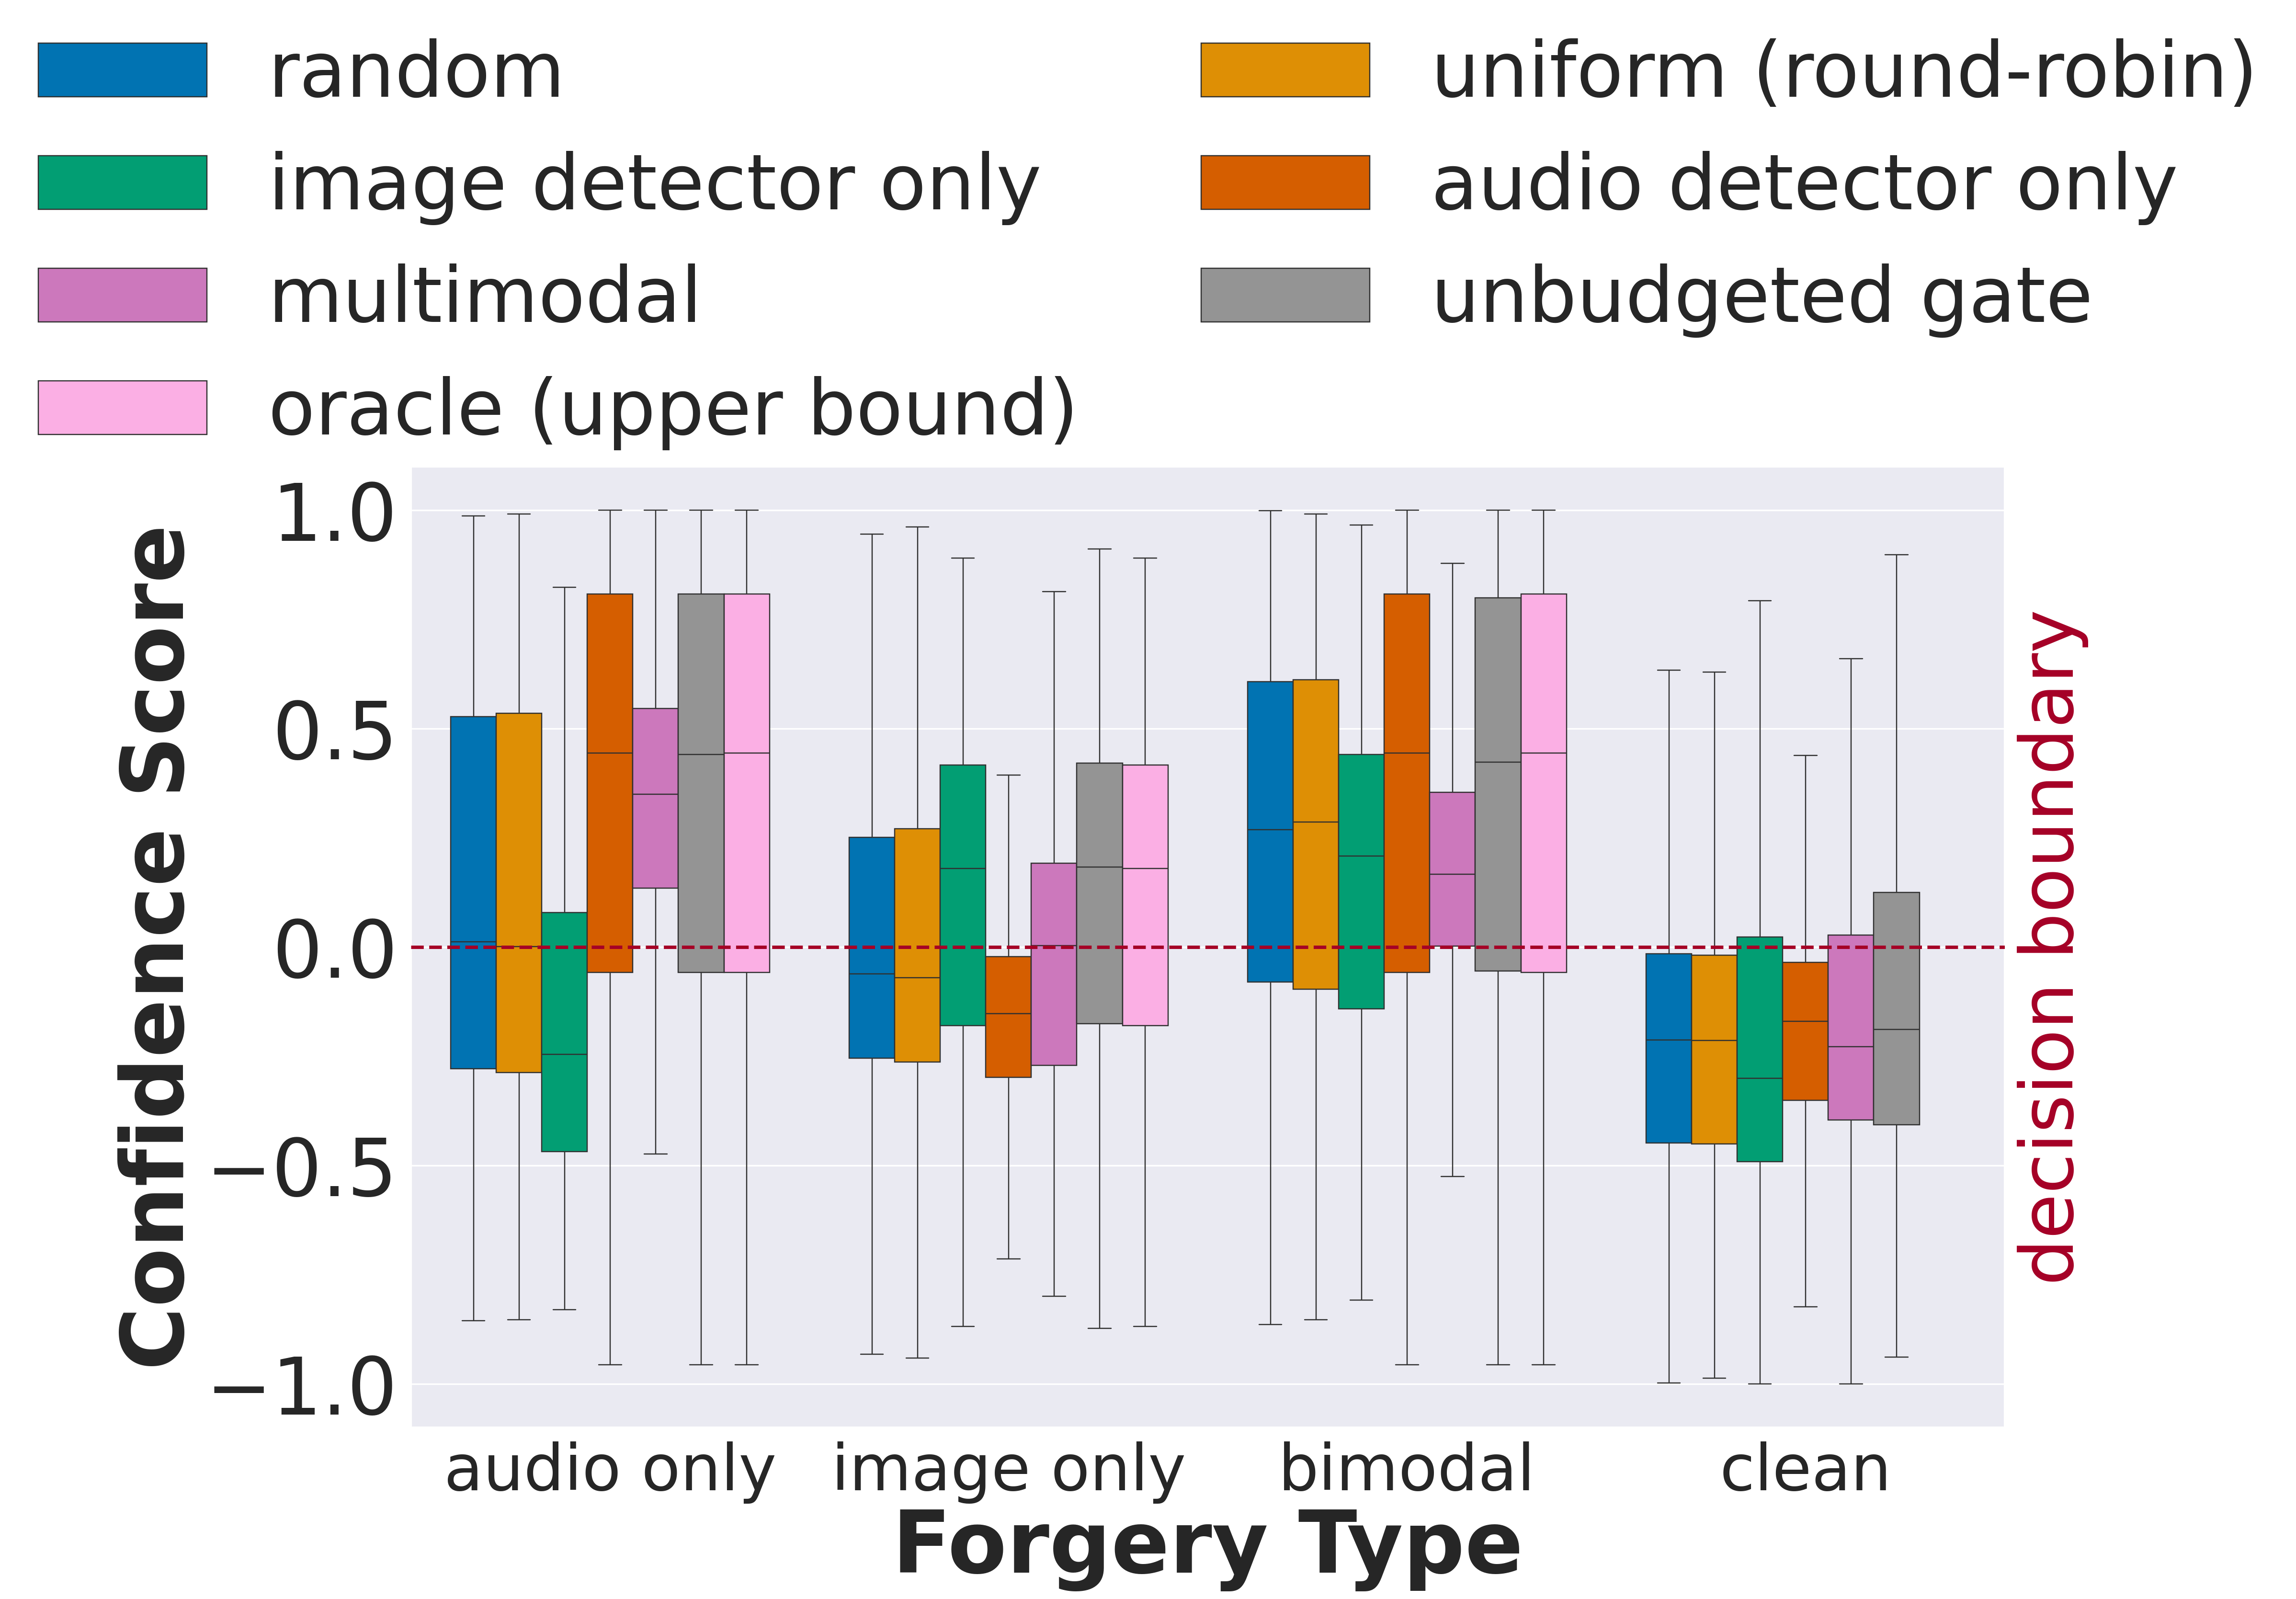

In [2]:
png, pdf = fig2.plot(DATA, os.path.join(OUT, "fig2.png"), overwrite=OVERWRITE)
display(Image(png, width=640))

## Fig. 3: does spending more help without knowing where to look?

Accuracy (the mean of recall and specificity over windows) against the budget fraction $\rho$. Lines are the mean of four router seeds; the band is the range over seeds.

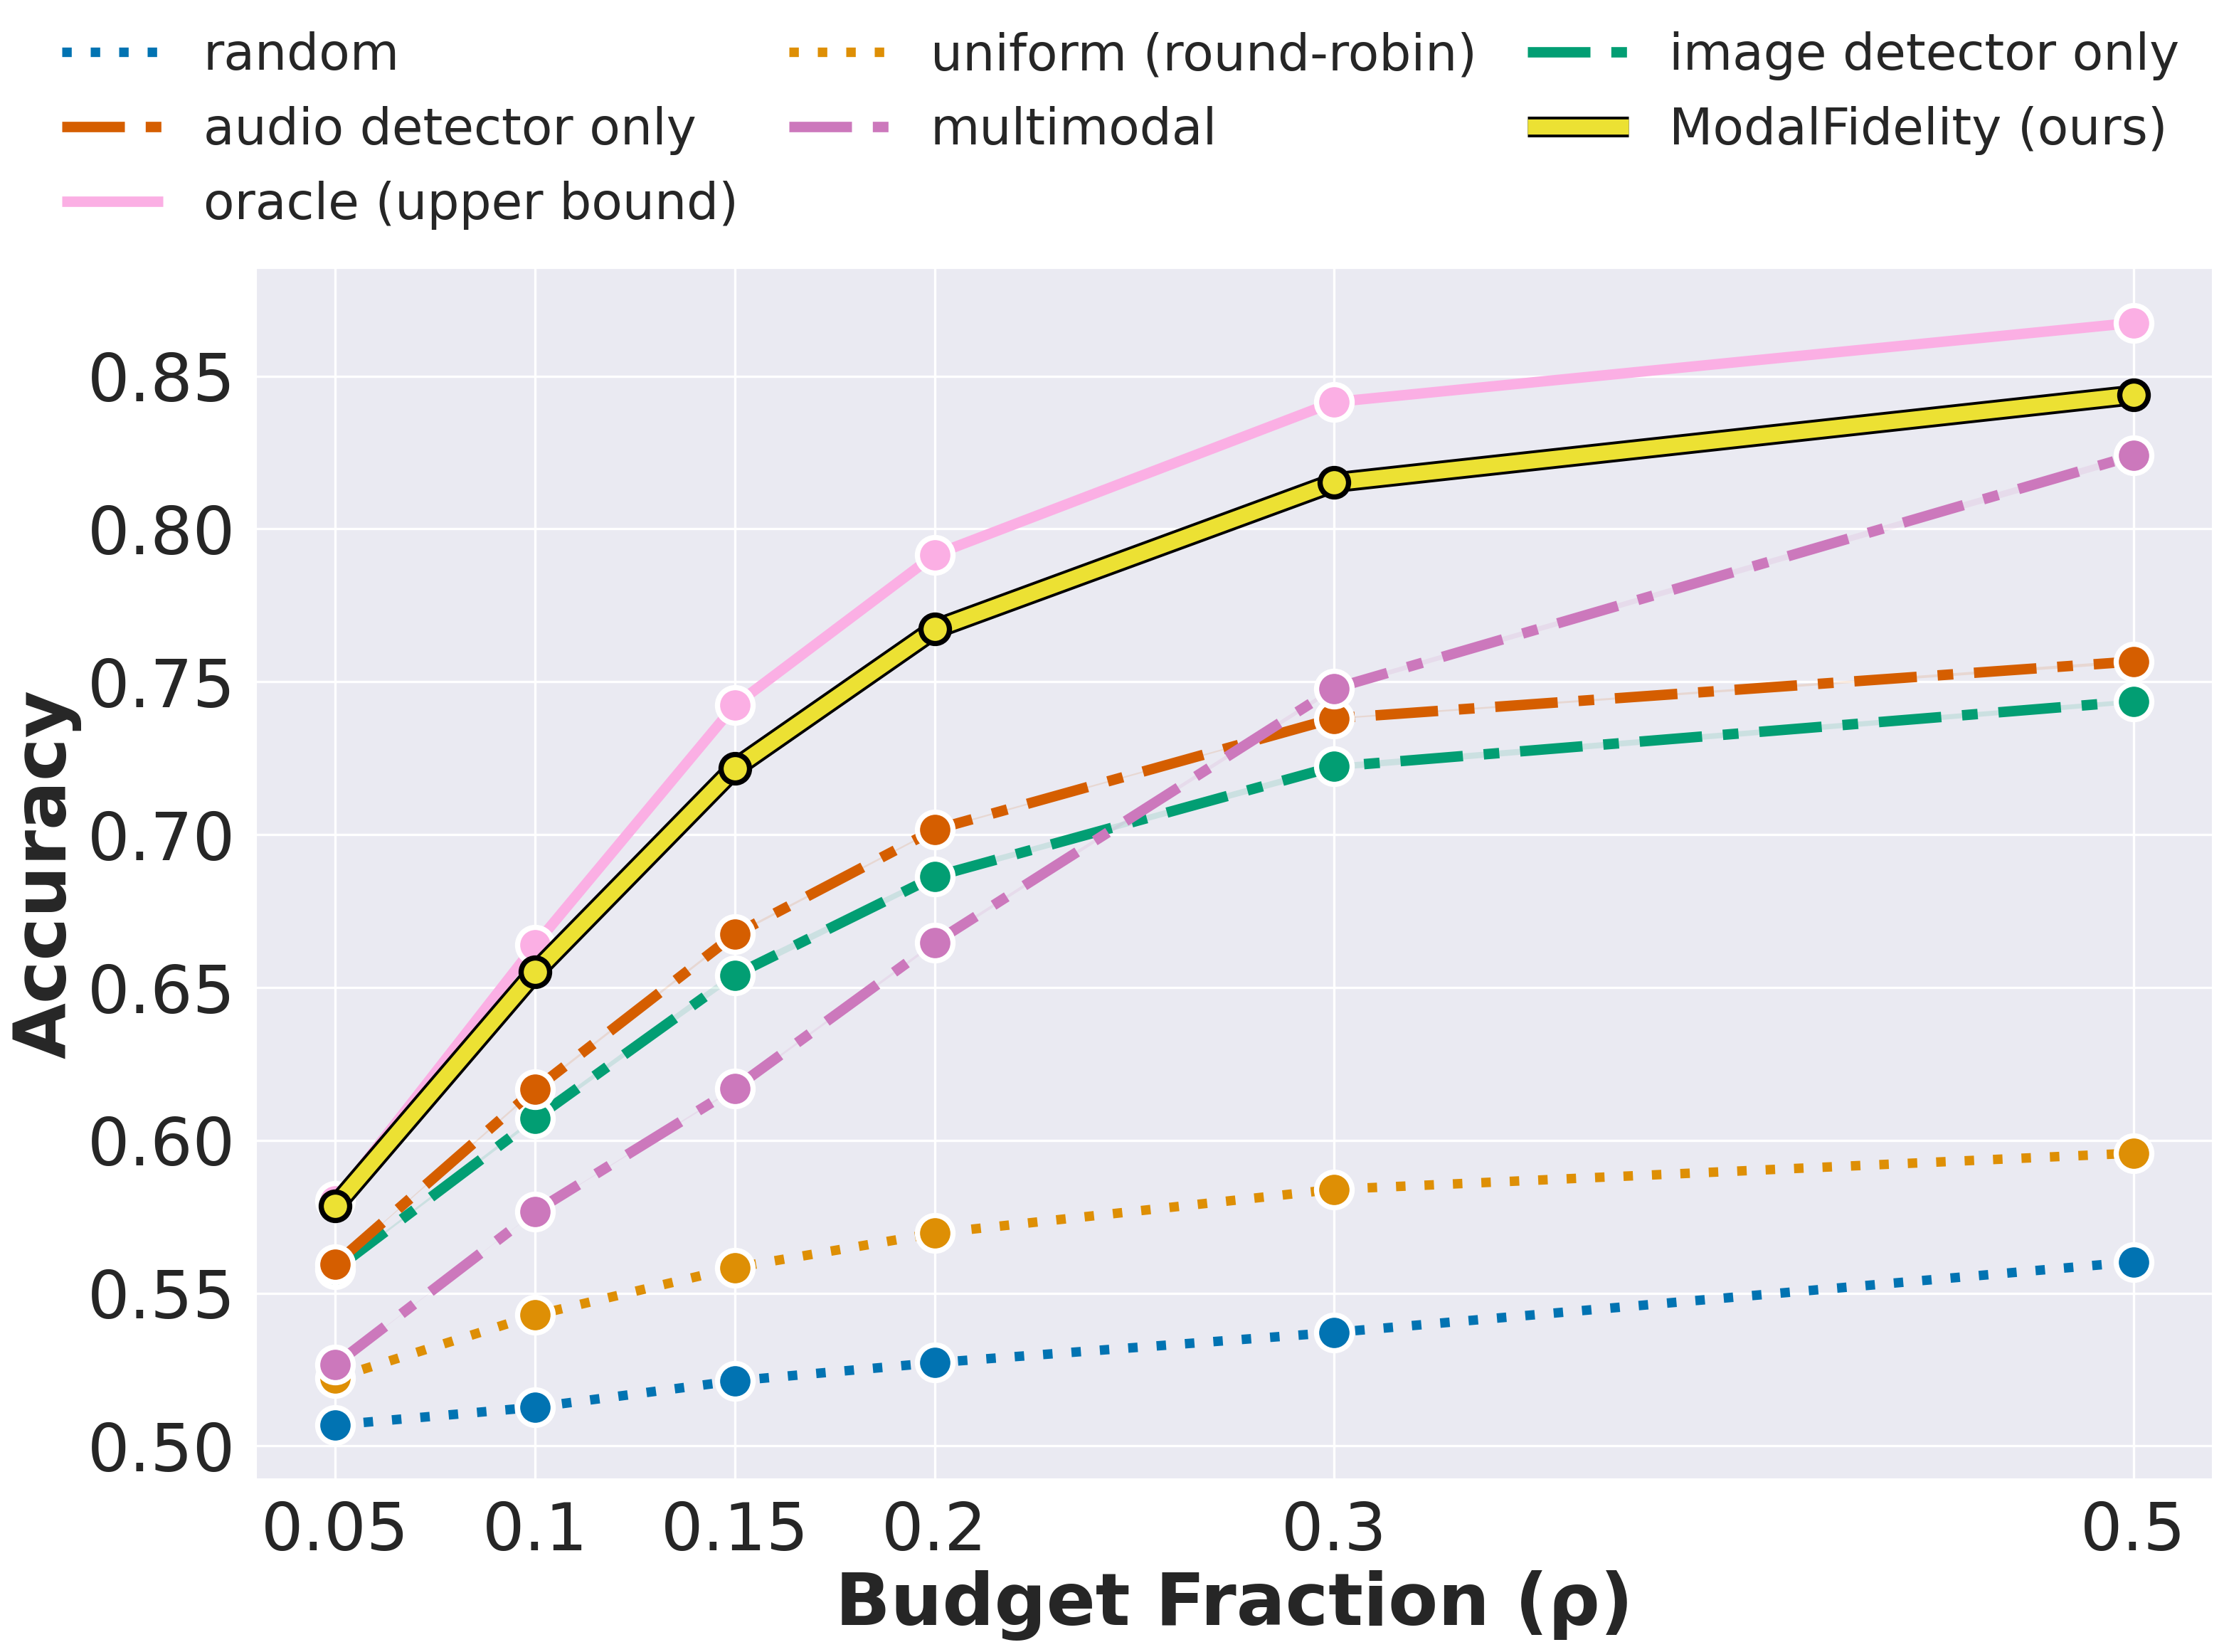

In [3]:
png, pdf = fig3.plot(DATA, os.path.join(OUT, "fig3.png"), overwrite=OVERWRITE)
display(Image(png, width=640))

## Table 1: why route before the detectors rather than after?

Late MoE gates run both detectors on every window. The router decides before any detector runs.

In [4]:
display(Markdown(table1.as_markdown(table1.load(DATA))))

| Placement | | Calls/win. (↓) | GFLOPs/win. (↓) | Acc. (↑) |
|---|---|---:|---:|---:|
| Late MoE | dense | 2.000 | 4086.6 | .7264 |
|  | feature | 2.000 | 4086.6 | .7298 |
|  | output | 2.000 | 4086.6 | .7322 |
| Input (ours) | ρ=0.20 | 0.130 | 257.5 | .7672 |
|  | ρ=0.30 | 0.161 | 327.3 | .8151 |
|  | ρ=0.50 | 0.183 | 384.5 | **.8444** |

## Every number the paper states about these results

Each row gives the paper's wording, the value recomputed from `data/`, and whether the paper's rounding holds.

In [5]:
import pandas as pd
from IPython.display import HTML

rows = claims.check(DATA)
table = pd.DataFrame(rows, columns=["claim", "paper", "recomputed", "match"])
# a fixed table id keeps the saved output identical from run to run
display(HTML(table.style.format({"recomputed": "{:.4f}"}).set_uuid("claims").to_html()))
assert table["match"].all(), "a paper number was not reproduced"
print(f"{table['match'].sum()}/{len(table)} paper numbers reproduced")

,claim,paper,recomputed,match
0,max gap to oracle (pp),within 2.6 pp of the oracle at every budget,2.6366,True
1,min share of oracle accuracy,retains over 96% of the oracle's accuracy,0.9687,True
2,router accuracy at rho=0.30,reaches 0.815 (rho = 0.30),0.8151,True
3,max gap to oracle for rho<=0.10 (pp),within 0.9 pp of the oracle for small budgets,0.8892,True
4,router accuracy at rho=0.10,reaches 0.655 (rho = 0.10),0.6550,True
5,best fixed detector at rho=0.10,at most 0.617 for any fixed detector,0.6167,True
6,best blind allocator at rho=0.10,0.543 for the blind allocators,0.5428,True
7,"blind allocators, lowest over budgets","near chance, 0.51 to 0.60",0.5069,True
8,"blind allocators, highest over budgets",upper end of near chance: 0.60,0.5958,True
9,router at rho=0.30 below the unbudgeted gate (pp),within 0.4 pp of the 0.819 of the unbudgeted gate,0.4327,True


28/28 paper numbers reproduced
